In [1]:
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
product_revenue = ''' WITH product_catt AS (SELECT product_id, product_category_name_english AS product_category
            FROM products AS p
            INNER JOIN product_category_name_translation AS pct
            ON p.product_category_name = pct.product_category_name)

            SELECT pc.product_category, SUM(o.price) AS revenue 
            FROM order_items AS o
            
            INNER JOIN product_catt AS pc
            ON o.product_id = pc.product_id
            GROUP BY pc.product_category
            ORDER BY revenue DESC;  '''
product_revenue_df = pd.read_sql(product_revenue,engine)


In [3]:
monthly_revenue = '''WITH order_value AS (SELECT order_id,SUM(payment_value) AS payment
                                          FROM order_payments
                                          GROUP BY order_id) 
                    SELECT TO_CHAR(o.order_purchase_timestamp, 'YYYY-MM') AS purchase_date, SUM(ov.payment) AS revenue
                    FROM orders AS o
                    INNER JOIN order_value AS ov
                    ON o.order_id = ov.order_id
                    WHERE o.order_status != 'canceled'
                    GROUP BY TO_CHAR(o.order_purchase_timestamp, 'YYYY-MM')
                    ORDER BY purchase_date ASC;'''
monthly_revenue_df = pd.read_sql(monthly_revenue,engine)
monthly_revenue_df['purchase_date'] = pd.to_datetime(monthly_revenue_df['purchase_date'], format='%Y-%m')

In [4]:
full_range = pd.date_range(start=monthly_revenue_df['purchase_date'].min(),
                            end=monthly_revenue_df['purchase_date'].max(),
                            freq='MS')  # MS = month start

monthly_revenue_df = (
    monthly_revenue_df.set_index('purchase_date').reindex(full_range, fill_value=0).rename_axis('purchase_date').reset_index()
)
monthly_revenue_df.drop(24,inplace=True) # last month's data was incomplete

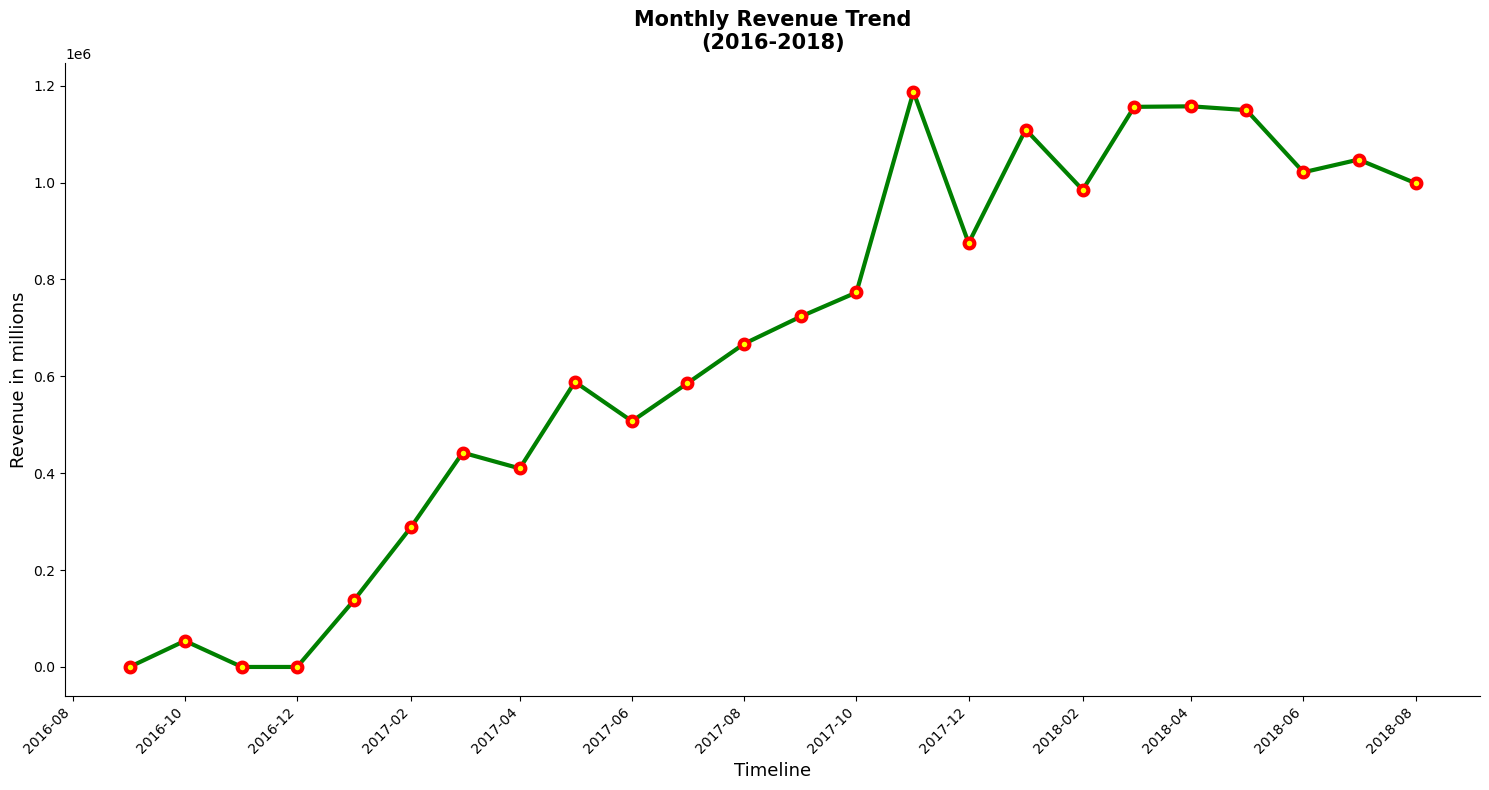

In [5]:
fig,ax = plt.subplots(figsize=(15,8))
plt.plot(monthly_revenue_df['purchase_date'],monthly_revenue_df['revenue'],lw=3,
         color='green',marker='o',markersize=7,markerfacecolor='yellow',markeredgecolor='red',markeredgewidth=3)
ax.set_title('Monthly Revenue Trend\n(2016-2018)',fontsize=15,weight='bold',pad=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=45)
ax.set_xlabel('Timeline',fontsize=13)
ax.set_ylabel('Revenue in millions',fontsize=13)
sns.despine()
plt.tight_layout()

- The platform started in late 2016 which relates to very low monthly revenue. Real growth started in early 2017.<br>
- Major standout here is November 2017 with a spike in revenue and his aligns with Black friday sale, worth confirming against order-level data.<br>
- From 2018 the revenue stays at 1.0-1.15M/month.

In [6]:
p_rev_df = product_revenue_df.head(50) #Rest of the product categories make too less of a revenue to actually compare

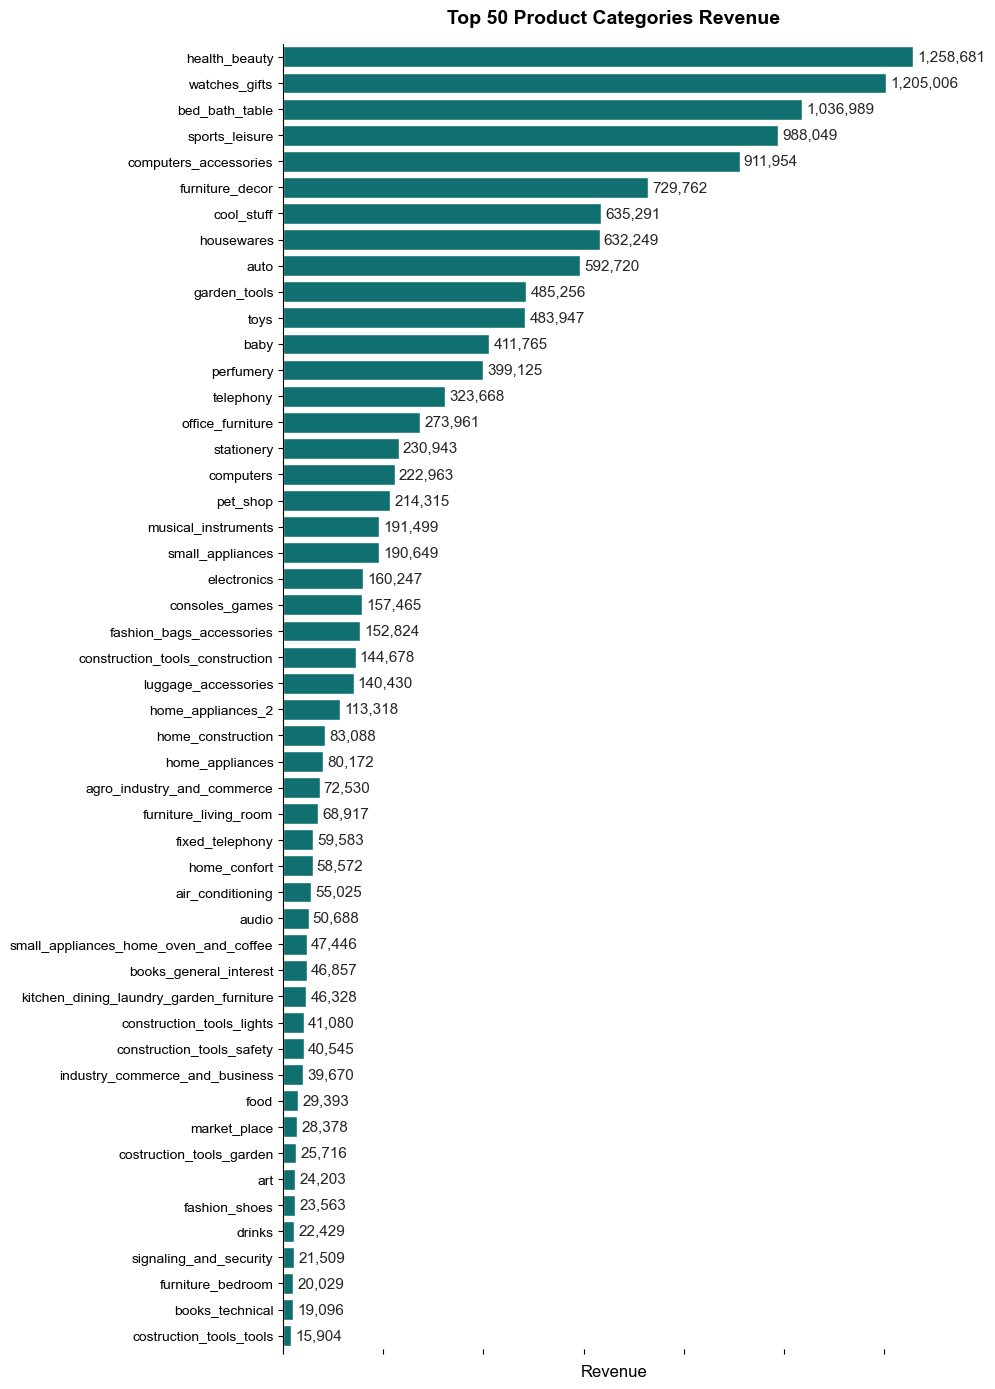

In [7]:
fig, ax = plt.subplots(figsize=(10, 14))
sns.set_style('ticks')
sns.barplot(x='revenue', y='product_category',data=p_rev_df,color='teal')
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3, fontsize=11)
ax.set_xlabel('Revenue', fontsize=12)
ax.set_ylabel('')
ax.set_title('Top 50 Product Categories Revenue', fontsize=14, weight='bold', pad=15)
ax.set_xticklabels([])
sns.despine(bottom=True)
plt.tight_layout()
plt.show()

The above bar chart gives a breakdown of Revenue made by Top 50 product categories.

In [8]:
# Exporting dataframe to csv for use in Tableau
monthly_revenue_df.to_csv('/Volumes/Air/Olist_exports_tableau/Monthly_revenue.csv', index=False)

In [9]:
# Exporting dataframe to csv for use in Tableau
product_revenue_df.to_csv('/Volumes/Air/Olist_exports_tableau/Product_category_revenue.csv', index=False)